In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import kstest, chi2

# Exercise 3 — Distribution Simulation & Testing

Generate *N* = 10 000 samples from each distribution using only U(0,1) uniforms.  
Verify by overlaying histograms with the analytical PDF and by formal goodness-of-fit tests (KS + χ²).

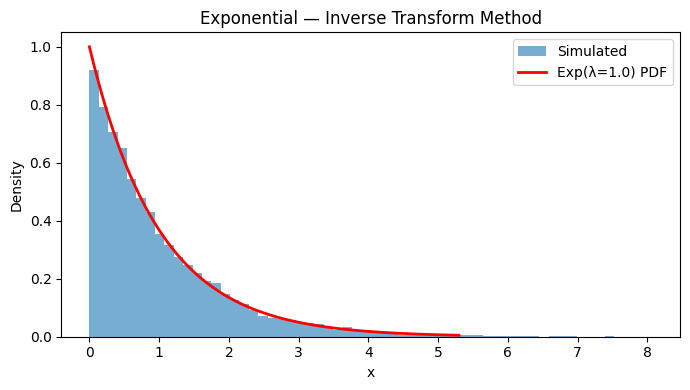

── KS test ──────────────────────────────────────────────────
  statistic : 0.00744   p = 0.6343   Reject H₀: False

── χ² test (50 equal-prob bins, df=49) ────────────────────
  statistic : 28.7300   critical : 66.3386   p = 0.9908   Reject H₀: False

  Sample: mean=1.0062  std=0.9971   (theoretical: mean=1.0000  std=1.0000)


In [17]:
# ── (a) Exponential Distribution ──────────────────────────────────────────────
# CDF: F(x) = 1 - e^(-λx)  →  Inverse transform: X = -ln(U) / λ

def sample_exponential(lam, n, rng):
    U = rng.uniform(size=n)
    return -np.log(U) / lam

N, lam = 10_000, 1.0
rng = np.random.default_rng(42)
exp_samples = sample_exponential(lam, N, rng)

dist_exp = stats.expon(scale=1 / lam)

# histogram vs PDF
x = np.linspace(0, dist_exp.ppf(0.995), 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(exp_samples, bins=60, density=True, alpha=0.6, label="Simulated")
ax.plot(x, dist_exp.pdf(x), "r-", lw=2, label=f"Exp(λ={lam}) PDF")
ax.set_xlabel("x"); ax.set_ylabel("Density")
ax.set_title("Exponential — Inverse Transform Method")
ax.legend(); plt.tight_layout(); plt.show()

# Kolmogorov-Smirnov test
ks_stat, ks_p = kstest(exp_samples, dist_exp.cdf)
print("── KS test ──────────────────────────────────────────────────")
print(f"  statistic : {ks_stat:.5f}   p = {ks_p:.4f}   Reject H₀: {ks_p < 0.05}")

# Chi-squared test with equal-probability bins (each bin has expected count N/B)
B = 50
edges = dist_exp.ppf(np.linspace(0, 1, B + 1))
edges[-1] = np.inf
obs = np.histogram(exp_samples, bins=edges)[0]
chi_stat = ((obs - N / B) ** 2 / (N / B)).sum()
chi_p = 1 - chi2.cdf(chi_stat, df=B - 1)
crit = chi2.ppf(0.95, df=B - 1)
print(f"\n── χ² test ({B} equal-prob bins, df={B-1}) ────────────────────")
print(f"  statistic : {chi_stat:.4f}   critical : {crit:.4f}   p = {chi_p:.4f}   Reject H₀: {chi_p < 0.05}")

print(f"\n  Sample: mean={exp_samples.mean():.4f}  std={exp_samples.std():.4f}   "
      f"(theoretical: mean={1/lam:.4f}  std={1/lam:.4f})")

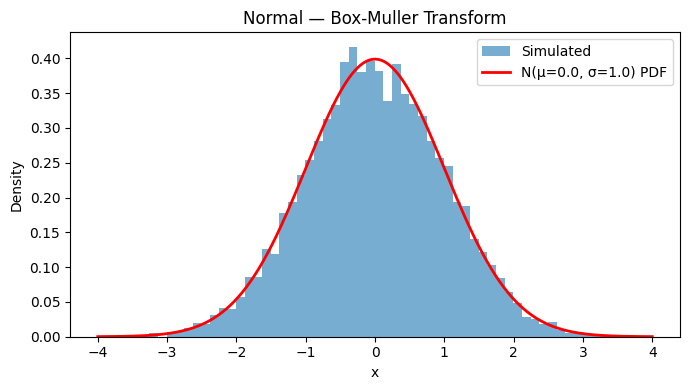

--------------
KS test:
-----
statistic : 0.00910   
p = 0.3773   
Reject H₀: False

---------------
Chi2 test (50 equal-prob bins, df=49): 
-----
statistic : 52.9200   
critical : 66.3386   
p = 0.3253   
Reject H₀: False

Sample: mean=-0.0020  std=1.0032   (theoretical: mean=0.0000  std=1.0000)


In [18]:
# ── (b) Normal Distribution — Box-Muller Transform ────────────────────────────
# U₁, U₂ ~ U(0,1):
#   Z₁ = √(-2 ln U₁) · cos(2π U₂)   ~  N(0,1)
#   Z₂ = √(-2 ln U₁) · sin(2π U₂)   ~  N(0,1)  (independent pair — use both)

def box_muller(mu, sigma, n, rng):
    m = (n + 1) // 2
    U1 = rng.uniform(size=m)
    U2 = rng.uniform(size=m)
    R = np.sqrt(-2 * np.log(U1))
    Z = np.concatenate([R * np.cos(2 * np.pi * U2),
                        R * np.sin(2 * np.pi * U2)])[:n]
    return mu + sigma * Z

N, mu, sigma = 10_000, 0.0, 1.0
rng = np.random.default_rng(42)
norm_samples = box_muller(mu, sigma, N, rng)

dist_norm = stats.norm(loc=mu, scale=sigma)

# histogram vs PDF
x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(norm_samples, bins=60, density=True, alpha=0.6, label="Simulated")
ax.plot(x, dist_norm.pdf(x), "r-", lw=2, label=f"N(μ={mu}, σ={sigma}) PDF")
ax.set_xlabel("x"); ax.set_ylabel("Density")
ax.set_title("Normal — Box-Muller Transform")
ax.legend(); plt.tight_layout(); plt.show()

# Kolmogorov-Smirnov test
ks_stat, ks_p = kstest(norm_samples, dist_norm.cdf)
print("--------------\nKS test:\n-----")
print(f"statistic : {ks_stat:.5f}   \np = {ks_p:.4f}   \nReject H₀: {ks_p < 0.05}")

# Chi-squared test with equal-probability bins
B = 50
edges = dist_norm.ppf(np.linspace(0, 1, B + 1))
edges[0], edges[-1] = -np.inf, np.inf
obs = np.histogram(norm_samples, bins=edges)[0]
chi_stat = ((obs - N / B) ** 2 / (N / B)).sum()
chi_p = 1 - chi2.cdf(chi_stat, df=B - 1)
crit = chi2.ppf(0.95, df=B - 1)
print(f"\n---------------\nChi2 test ({B} equal-prob bins, df={B-1}): \n-----")
print(f"statistic : {chi_stat:.4f}   \ncritical : {crit:.4f}   \np = {chi_p:.4f}   \nReject H₀: {chi_p < 0.05}")

print(f"\nSample: mean={norm_samples.mean():.4f}  std={norm_samples.std():.4f}   "
      f"(theoretical: mean={mu:.4f}  std={sigma:.4f})")

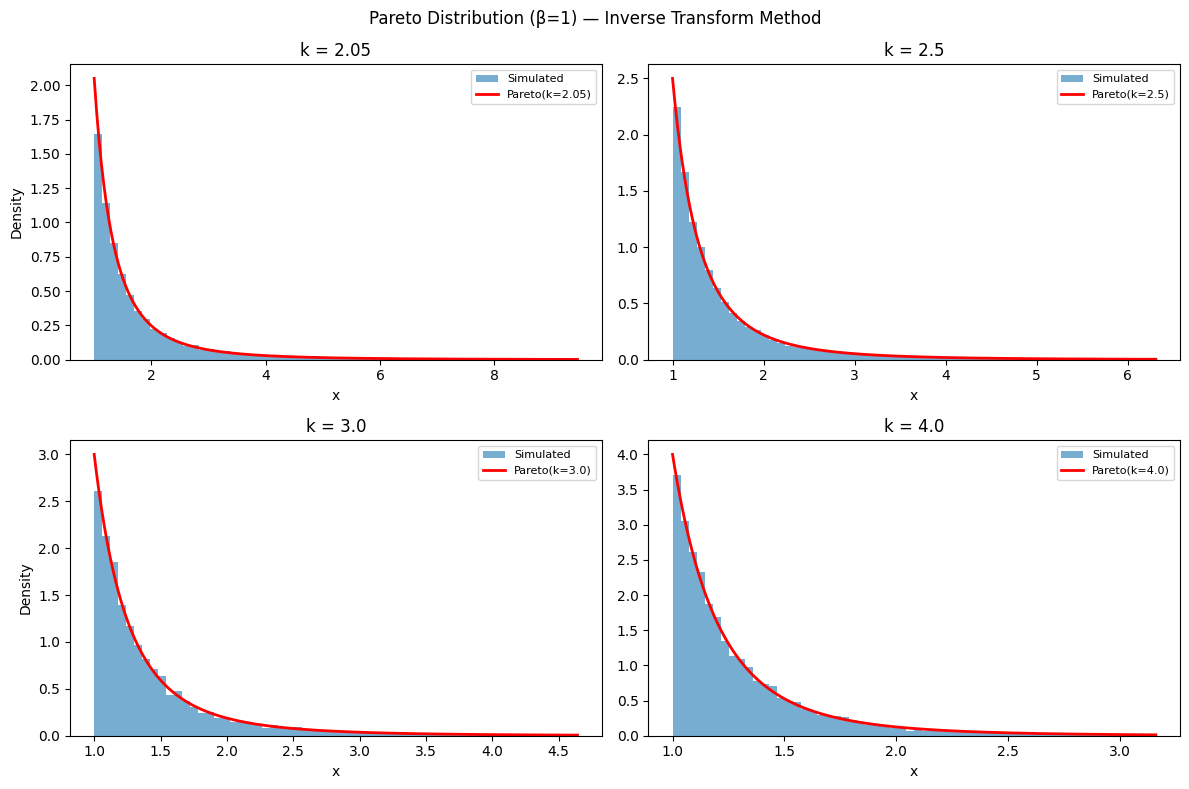


     k     KS stat      KS p     χ² stat      χ² p    Mean(th)     Var(th)
──────────────────────────────────────────────────────────────────────────
  2.05     0.01253    0.0859     50.4900    0.4144      1.9524     37.1882
   2.5     0.00965    0.3072     33.8700    0.9508      1.6667      2.2222
   3.0     0.00729    0.6606     47.3500    0.5402      1.5000      0.7500
   4.0     0.00608    0.8514     32.6700    0.9649      1.3333      0.2222


In [20]:
# ── (c) Pareto Distribution — β=1, k ∈ {2.05, 2.5, 3, 4} ─────────────────────
# PDF: f(x) = k β^k / x^(k+1)   for x ≥ β
# CDF: F(x) = 1 - (β/x)^k       for x ≥ β
# Inverse transform: X = β · U^(-1/k)   (from solving F(X) = U)
#
# Moments: Mean = kβ/(k-1) [k>1]   Var = kβ²/((k-2)(k-1)²) [k>2]
# k=2.05 → variance barely finite (heavy-tailed);  k=4 → much lighter tail
np.random.seed(42)

def sample_pareto(beta, k, n):
    U = np.random.uniform(size=n)
    return beta * U ** (-1.0 / k)

beta = 1.0
k_values = [2.05, 2.5, 3.0, 4.0]
N = 10_000
B = 50  # chi-squared bins

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

summary = []
for col, k in enumerate(k_values):
    ax = axes[col // 2, col % 2]
    samples = sample_pareto(beta, k, N)
    dist_par = stats.pareto(b=k, scale=beta)

    x_max = dist_par.ppf(0.99)
    x = np.linspace(beta, x_max, 400)

    ax.hist(samples[samples <= x_max], bins=60, density=True,
            alpha=0.6, label="Simulated")
    ax.plot(x, dist_par.pdf(x), "r-", lw=2, label=f"Pareto(k={k})")
    ax.set_title(f"k = {k}"); ax.set_xlabel("x")
    if col % 2 == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

    # KS test
    ks_stat, ks_p = kstest(samples, dist_par.cdf)

    # Chi-squared with equal-probability bins
    edges = dist_par.ppf(np.linspace(0, 1, B + 1))
    edges[-1] = np.inf
    obs = np.histogram(samples, bins=edges)[0]
    chi_stat = ((obs - N / B) ** 2 / (N / B)).sum()
    chi_p = 1 - chi2.cdf(chi_stat, df=B - 1)

    mean_th = k * beta / (k - 1)
    var_th = k * beta**2 / ((k - 2) * (k - 1)**2) if k > 2 else float("inf")
    var_str = "∞" if np.isinf(var_th) else f"{var_th:.4f}"

    summary.append((k, ks_stat, ks_p, chi_stat, chi_p, mean_th, var_str))

plt.suptitle("Pareto Distribution (β=1) — Inverse Transform Method")
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'k':>6}  {'KS stat':>10}  {'KS p':>8}  {'χ² stat':>10}  {'χ² p':>8}  "
      f"{'Mean(th)':>10}  {'Var(th)':>10}")
print("─" * 74)
for k, ks_s, ks_p, chi_s, chi_p, mean_th, var_str in summary:
    print(f"{k:>6}  {ks_s:>10.5f}  {ks_p:>8.4f}  {chi_s:>10.4f}  {chi_p:>8.4f}  "
          f"{mean_th:>10.4f}  {var_str:>10}")

     k     E[X] (th)    E[X] (samp)     Var(X) (th)   Var(X) (samp)
──────────────────────────────────────────────────────────────────
  2.05        1.9524         1.9999         37.1882         15.4829
   2.5        1.6667         1.6881          2.2222          3.0522
   3.0        1.5000         1.5122          0.7500          0.9832
   4.0        1.3333         1.3397          0.2222          0.2586


C:\Users\Vikto\AppData\Local\Temp\ipykernel_13512\213889896.py:30: RuntimeWarning: invalid value encountered in divide
  (cumsum2 / ns - run_mean ** 2) * ns / (ns - 1),


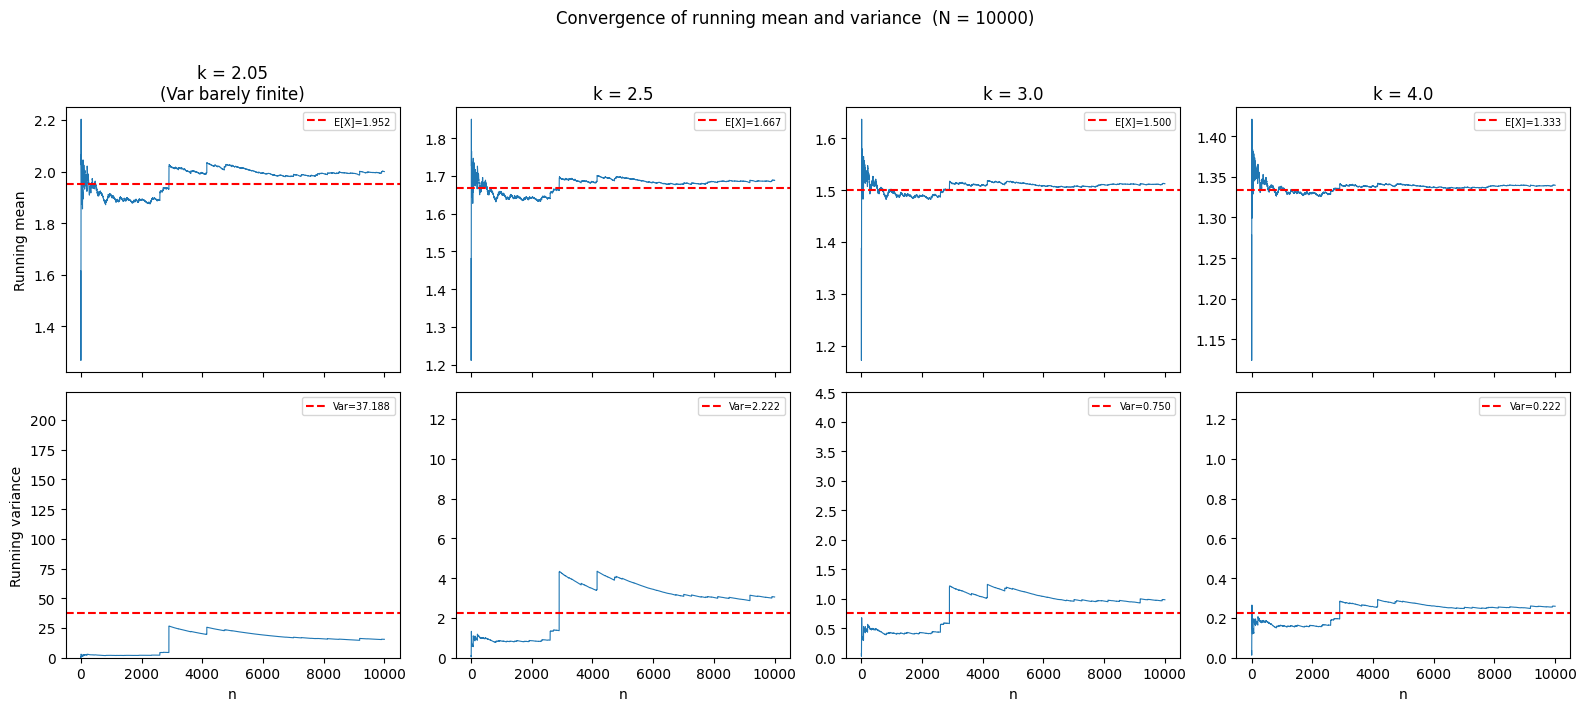


Problems
────────
k = 2.05  Var(X) = β²·k / ((k-1)²·(k-2)) ≈ 37.2  (finite, but k-2 = 0.05 ≈ 0 makes
          it enormous).  The running variance plot shows large erratic jumps: a single
          extreme draw (e.g. x ~ 100) can shift the estimate by tens of units.  With
          N = 10 000 the sample variance is a highly unreliable estimate of 37.2.

k > 2     Variance is finite and more moderate.  The running variance converges
          smoothly; k = 4 is the fastest because the tail is lightest.

General   All four k values have INFINITE kurtosis (requires k > 4 for finite
          kurtosis).  This means the CLT for the variance estimator converges very
          slowly regardless of k — heavy tails produce occasional huge samples that
          dominate the sum of squares.  For k ≤ 2 (not shown here) the variance
          itself would be infinite and the running variance would diverge without bound.



In [ ]:
# ── Mean & Variance: sample vs theoretical ────────────────────────────────────

# Comparison table
print(f"{'k':>6}  {'E[X] (th)':>12}  {'E[X] (samp)':>13}  {'Var(X) (th)':>14}  {'Var(X) (samp)':>14}")
print("─" * 66)
for k in k_values:
    np.random.seed(42)
    s = sample_pareto(beta, k, N)
    mean_th = k * beta / (k - 1)
    var_th  = k * beta**2 / ((k - 2) * (k - 1)**2) if k > 2 else float("inf")
    var_str = f"{var_th:>14.4f}" if not np.isinf(var_th) else f"{'∞':>14}"
    print(f"{k:>6}  {mean_th:>12.4f}  {s.mean():>13.4f}  {var_str}  {s.var(ddof=1):>14.4f}")

# Running mean and variance — convergence as function of sample size
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
ns = np.arange(1, N + 1)

titles = ["k = 2.05\n(Var barely finite)", "k = 2.5", "k = 3.0", "k = 4.0"]
for col, k in enumerate(k_values):
    np.random.seed(42)
    s = sample_pareto(beta, k, N)
    mean_th = k * beta / (k - 1)
    var_th  = k * beta**2 / ((k - 2) * (k - 1)**2) if k > 2 else float("inf")

    cumsum  = np.cumsum(s)
    cumsum2 = np.cumsum(s ** 2)
    run_mean = cumsum / ns
    # unbiased running variance via cumulative sums
    run_var = np.where(ns > 1,
                       (cumsum2 / ns - run_mean ** 2) * ns / (ns - 1),
                       np.nan)

    ax1 = axes[0, col]
    ax1.plot(ns, run_mean, lw=0.8)
    ax1.axhline(mean_th, color="r", lw=1.5, ls="--", label=f"E[X]={mean_th:.3f}")
    ax1.set_title(titles[col])
    ax1.legend(fontsize=7)
    if col == 0:
        ax1.set_ylabel("Running mean")

    ax2 = axes[1, col]
    ax2.plot(ns[1:], run_var[1:], lw=0.8)
    if not np.isinf(var_th):
        ax2.axhline(var_th, color="r", lw=1.5, ls="--", label=f"Var={var_th:.3f}")
        ax2.set_ylim(0, var_th * 6)
    ax2.legend(fontsize=7)
    ax2.set_xlabel("n")
    if col == 0:
        ax2.set_ylabel("Running variance")

plt.suptitle(f"Convergence of running mean and variance  (N = {N})", y=1.01)
plt.tight_layout()
plt.show()

print("""
Problems
────────
k = 2.05  Var(X) = β²·k / ((k-1)²·(k-2)) ≈ 37.2  (finite, but k-2 = 0.05 ≈ 0 makes it enormous).
    The running variance plot shows large erratic jumps: a single extreme draw (e.g. x ~ 100) can
    shift the estimate by tens of units.  With N = 10 000 the sample variance is a highly unreliable estimate of 37.2.

k > 2     Variance is finite and more moderate.  The running variance converges smoothly; 
    k = 4 is the fastest because the tail is lightest.

General   All four k values have INFINITE kurtosis (requires k > 4 for finite kurtosis).
    This means the CLT for the variance estimator converges very slowly regardless of k,
    heavy tails produce occasional huge samples that dominate the sum of squares.
    For k ≤ 2 (not shown here) the variance itself would be infinite and the running variance would diverge without bound.
""")

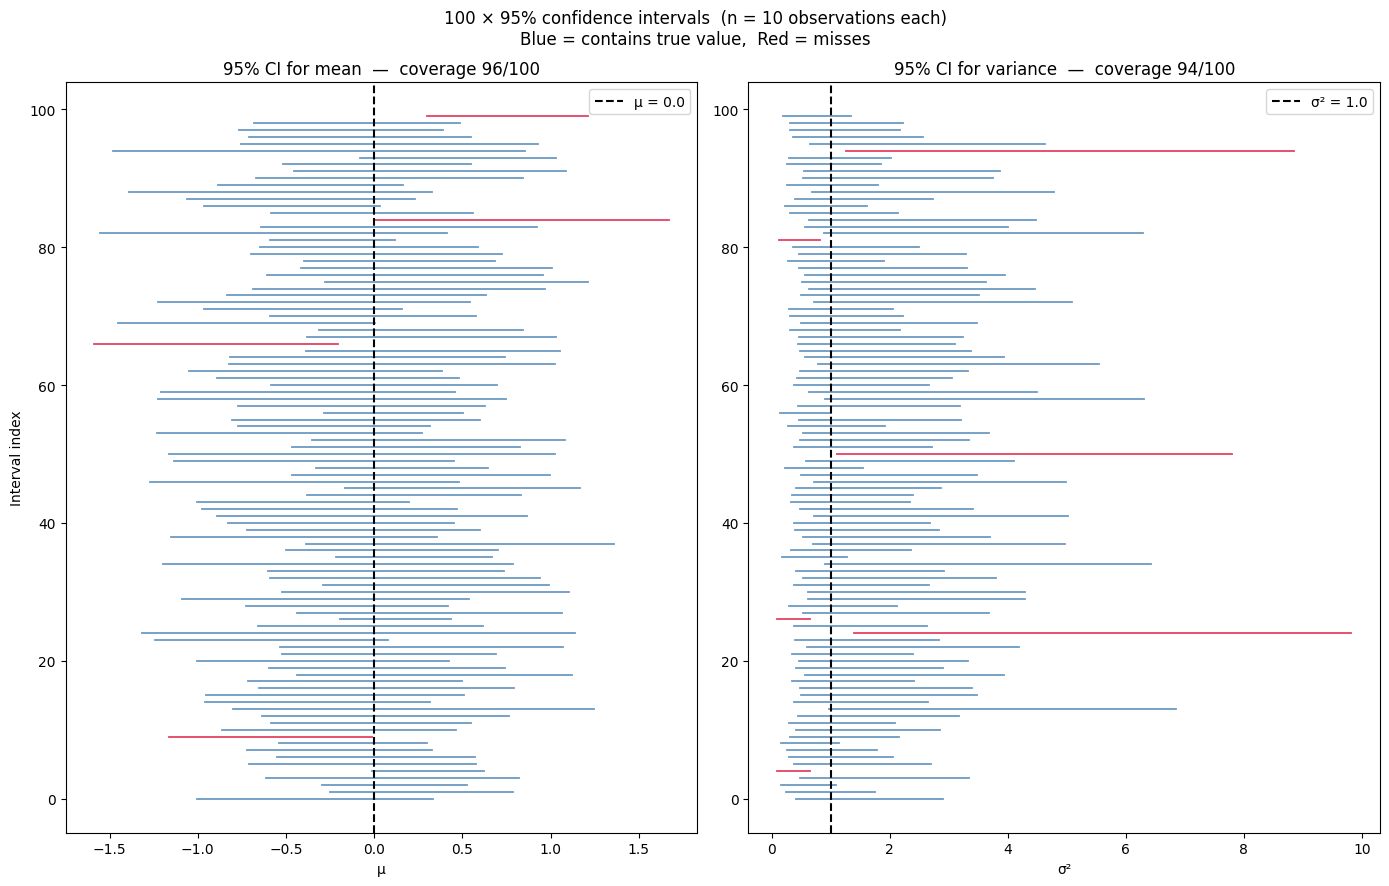

t critical value  : t(0.025, 9) = 2.2622
χ² critical values: χ²(0.025, 9) = 2.7004,  χ²(0.975, 9) = 19.0228

CI width — mean    : mean = 1.3782  std = 0.3283
CI width — variance: mean = 2.8044  std = 1.3625

Coverage  mean: 96/100    variance: 94/100    (nominal: 95/100)

Discussion
──────────
Coverage
  With 100 independent 95% CIs we expect ~95 to cover the true value and ~5 to miss
  (shown in red).  The observed counts should be close to 95; any deviation is random
  fluctuation (std ≈ √(100·0.05·0.95) ≈ 2.2).

Width — mean CI
  The t critical value t(0.025, 9) ≈ 2.26 is larger than z(0.025) = 1.96 used for
  large samples, so the intervals are wider than the asymptotic case.  With n=10 the
  half-width is about 0.7 σ, which is quite imprecise for practical purposes.

Width — variance CI
  The chi-squared CI is ASYMMETRIC: the upper bound extends much further above s²
  than the lower bound reaches below it.  This is because χ²(0.025, 9) ≈ 2.70 is
  much smaller than χ²(0.975, 9) ≈

In [19]:
# ── 95% Confidence Intervals for mean and variance (n=10, 100 replications) ───
# CI for mean     : x̄ ± t(α/2, n-1) · s/√n          (t-distribution, df=n-1)
# CI for variance : [(n-1)s²/χ²(1-α/2), (n-1)s²/χ²(α/2)]  (chi-squared, df=n-1)

n, M, alpha = 10, 100, 0.05
mu_true, sigma2_true = 0.0, 1.0

rng = np.random.default_rng(42)
obs = rng.normal(mu_true, np.sqrt(sigma2_true), size=(M, n))  # (100, 10)

xbar = obs.mean(axis=1)
s    = obs.std(axis=1, ddof=1)
s2   = s ** 2

# CI for mean
t_crit    = stats.t.ppf(1 - alpha / 2, df=n - 1)
ci_mu_lo  = xbar - t_crit * s / np.sqrt(n)
ci_mu_hi  = xbar + t_crit * s / np.sqrt(n)

# CI for variance (asymmetric chi-squared bounds)
chi2_lo   = stats.chi2.ppf(alpha / 2,     df=n - 1)
chi2_hi   = stats.chi2.ppf(1 - alpha / 2, df=n - 1)
ci_var_lo = (n - 1) * s2 / chi2_hi
ci_var_hi = (n - 1) * s2 / chi2_lo

cover_mu  = (ci_mu_lo  <= mu_true)     & (mu_true     <= ci_mu_hi)
cover_var = (ci_var_lo <= sigma2_true) & (sigma2_true <= ci_var_hi)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 9))

for i in range(M):
    c = "steelblue" if cover_mu[i] else "crimson"
    ax1.plot([ci_mu_lo[i], ci_mu_hi[i]], [i, i], color=c, lw=1.3, alpha=0.8)
ax1.axvline(mu_true, color="black", lw=1.5, ls="--", label=f"μ = {mu_true}")
ax1.set_xlabel("μ"); ax1.set_ylabel("Interval index")
ax1.set_title(f"95% CI for mean  —  coverage {cover_mu.sum()}/100")
ax1.legend()

for i in range(M):
    c = "steelblue" if cover_var[i] else "crimson"
    ax2.plot([ci_var_lo[i], ci_var_hi[i]], [i, i], color=c, lw=1.3, alpha=0.8)
ax2.axvline(sigma2_true, color="black", lw=1.5, ls="--", label=f"σ² = {sigma2_true}")
ax2.set_xlabel("σ²")
ax2.set_title(f"95% CI for variance  —  coverage {cover_var.sum()}/100")
ax2.legend()

plt.suptitle(f"100 × 95% confidence intervals  (n = {n} observations each)\n"
             f"Blue = contains true value,  Red = misses")
plt.tight_layout()
plt.show()

# Numerical summary
print(f"t critical value  : t(0.025, {n-1}) = {t_crit:.4f}")
print(f"χ² critical values: χ²(0.025, {n-1}) = {chi2_lo:.4f},  χ²(0.975, {n-1}) = {chi2_hi:.4f}")
print(f"\nCI width — mean    : mean = {(ci_mu_hi  - ci_mu_lo ).mean():.4f}  "
      f"std = {(ci_mu_hi  - ci_mu_lo ).std():.4f}")
print(f"CI width — variance: mean = {(ci_var_hi - ci_var_lo).mean():.4f}  "
      f"std = {(ci_var_hi - ci_var_lo).std():.4f}")
print(f"\nCoverage  mean: {cover_mu.sum()}/100    variance: {cover_var.sum()}/100    (nominal: 95/100)")

print("""
Discussion
──────────
Coverage
  With 100 independent 95% CIs we expect ~95 to cover the true value and ~5 to miss
  (shown in red).  The observed counts should be close to 95; any deviation is random
  fluctuation (std ≈ √(100·0.05·0.95) ≈ 2.2).

Width — mean CI
  The t critical value t(0.025, 9) ≈ 2.26 is larger than z(0.025) = 1.96 used for
  large samples, so the intervals are wider than the asymptotic case.  With n=10 the
  half-width is about 0.7 σ, which is quite imprecise for practical purposes.

Width — variance CI
  The chi-squared CI is ASYMMETRIC: the upper bound extends much further above s²
  than the lower bound reaches below it.  This is because χ²(0.025, 9) ≈ 2.70 is
  much smaller than χ²(0.975, 9) ≈ 19.02, giving a right tail that is roughly
  7× longer than the left tail.

Small n
  With only n=10 both CIs are very wide — we gain little precision about the true
  parameters.  Widths shrink as 1/√n, so quadrupling observations halves the width.
""")

In [24]:
def sample_pareto_composition(beta, k, n, rng):
    lam = rng.gamma(shape=k, scale=1.0 / beta, size=n)  # λ ~ Gamma(k, rate=β)
    X   = rng.exponential(scale=1.0 / lam)               # X|λ ~ Exp(λ)
    return X + beta                                        # shift → [β, ∞)

def sample_pareto_min(beta, k, n, rng):
    """Order-statistics method — only valid for integer k."""
    k = int(k)
    U = rng.uniform(size=(n, k))
    return np.min(beta / U, axis=1)                        # min of k Pareto(β,1)

     k                Method     KS stat      KS p        Mean           Var
----------------------------------------------------------------------------
  2.05           Composition     0.00554    0.9173      1.9608        6.6039
                 Theoretical                            1.9524  37.18820861678019

   2.5           Composition     0.00604    0.8562      1.6670        1.6204
                 Theoretical                            1.6667  2.2222222222222223

   3.0           Composition     0.00841    0.4767      1.4976        0.6707
   3.0  min of 3 Pareto(β,1)     0.00828    0.4974      1.4963        0.6909
                 Theoretical                            1.5000          0.75

   4.0           Composition     0.01014    0.2533      1.3389        0.2552
   4.0  min of 4 Pareto(β,1)     0.00613    0.8439      1.3321        0.2411
                 Theoretical                            1.3333  0.2222222222222222



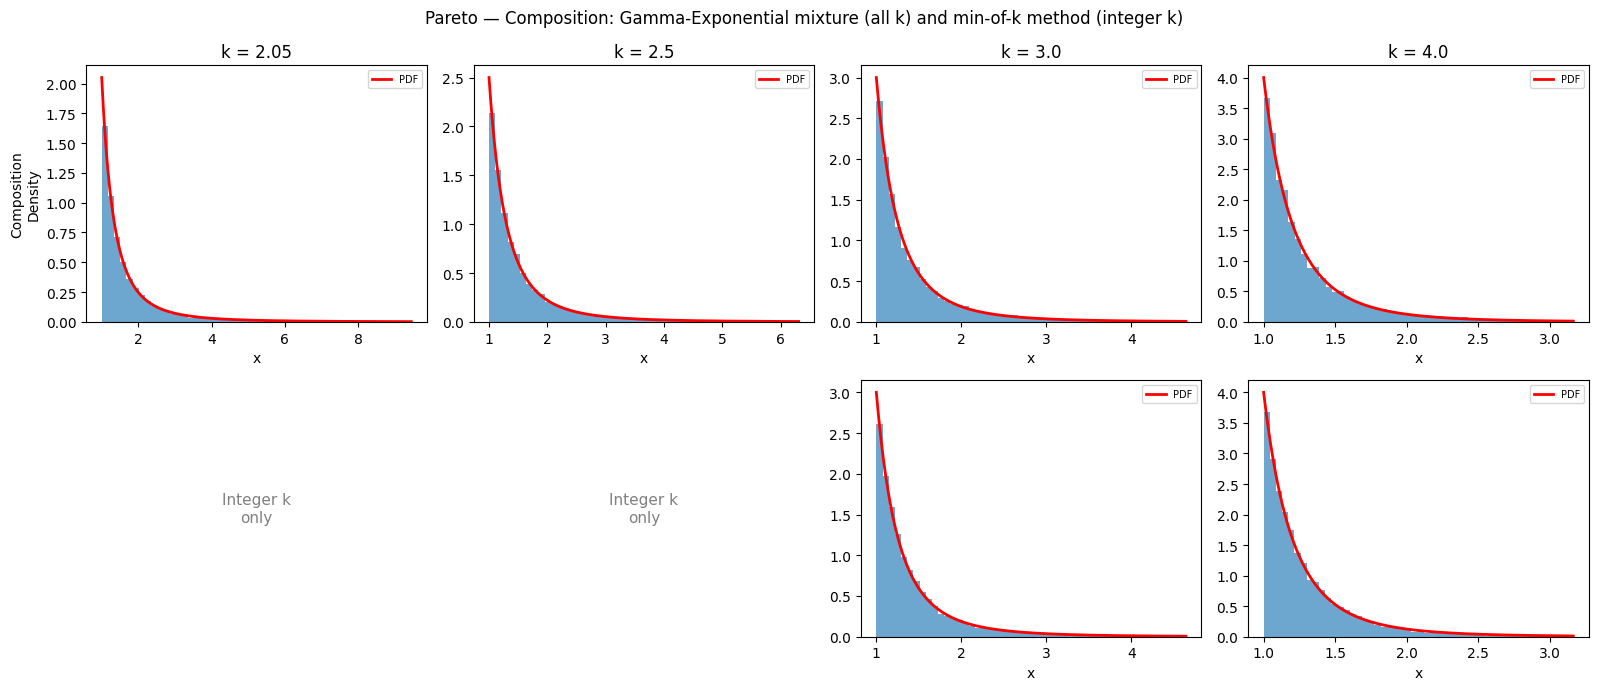

In [25]:
# Pareto via Composition (Gamma–Exponential mixture) 
#
# Key identity: if Y = log(X/β) then Y ~ Exp(k).
# For non-integer k we use the scale-mixture representation:
#
#   Step 1.  λ  ~ Gamma(shape=k, rate=β)   — draw a random rate
#   Step 2.  X|λ ~ Exponential(rate=λ)     — draw exponential given that rate
#   Step 3.  Y  = X + β                    — shift support to [β, ∞)
#
# Marginalising over λ recovers Pareto(β, k):
#   f(y) = ∫₀^∞ λ e^{-λ(y-β)} · [β^k λ^{k-1} e^{-βλ} / Γ(k)] dλ
#        = k β^k · Γ(k+1)/Γ(k) / y^{k+1}  =  k β^k / y^{k+1}   ✓
#
# For integer k a second, simpler route exists via order statistics:
#   min(X₁,…,Xₖ)  where Xᵢ ~ Pareto(β,1) = β/Uᵢ
#   has survival P(min > y) = (β/y)^k  →  Pareto(β, k)

N = 10000
beta = 1.0
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

print(f"{'k':>6}  {'Method':>20}  {'KS stat':>10}  {'KS p':>8}  "
      f"{'Mean':>10}  {'Var':>12}")
print("-" * 76)

for col, k in enumerate(k_values):
    dist  = stats.pareto(b=k, scale=beta)
    x_max = dist.ppf(0.99)
    x_pdf = np.linspace(beta, x_max, 400)

    rng1 = np.random.default_rng(42)
    rng2 = np.random.default_rng(42)
    s_comp = sample_pareto_composition(beta, k, N, rng1)
    s_min  = sample_pareto_min(beta, k, N, rng2) if k == int(k) else None

    for row, (s, label) in enumerate([(s_comp, "Composition"),
                                       (s_min,  f"min of {int(k)} Pareto(β,1)")]):
        ax = axes[row, col]
        if s is None:
            ax.text(0.5, 0.5, "Integer k\nonly", transform=ax.transAxes,
                    ha="center", va="center", fontsize=11, color="grey")
            ax.set_title(f"k = {k}" if row == 0 else "")
            ax.axis("off")
            continue

        ax.hist(s[s <= x_max], bins=50, density=True, alpha=0.65)
        ax.plot(x_pdf, dist.pdf(x_pdf), "r-", lw=2, label="PDF")
        ax.set_title(f"k = {k}" if row == 0 else "")
        ax.set_xlabel("x")
        if col == 0:
            ax.set_ylabel(label + "\nDensity")
        ax.legend(fontsize=7)

        ks_s, ks_p = kstest(s, dist.cdf)
        var_th = k * beta**2 / ((k-2)*(k-1)**2) if k > 2 else float("inf")
        print(f"{k:>6}  {label:>20}  {ks_s:>10.5f}  {ks_p:>8.4f}  "
              f"{s.mean():>10.4f}  {s.var(ddof=1):>12.4f}")

    mean_th = k * beta / (k - 1)
    var_th  = k * beta**2 / ((k-2)*(k-1)**2) if k > 2 else float("inf")
    print(f"{'':>6}  {'Theoretical':>20}  {'':>10}  {'':>8}  "
          f"{mean_th:>10.4f}  {var_th if not np.isinf(var_th) else '∞':>12}")
    print()

plt.suptitle("Pareto — Composition: Gamma-Exponential mixture (all k) "
             "and min-of-k method (integer k)")
plt.tight_layout()
plt.show()